In [7]:
!pip install -U -q pip
!pip install -q torch torchvision

In [25]:
import torch
import torchvision

In [72]:
img = torchvision.io.decode_image('image.png')
print(img.device)
img = img.to("cuda")
print(img.device)

cpu
cuda:0


<class 'torch.Tensor'>, torch.uint8, torch.Size([4, 1024, 1024])
cuda:0


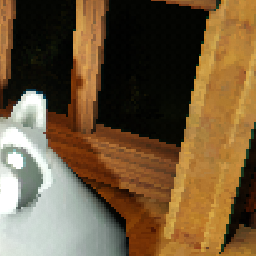

In [74]:
print(f"{type(img)}, {img.dtype}, {img.shape}")
transform = torchvision.transforms.v2.RandomCrop(size=(256, 256))
out = transform(img)
print(out.device)
display(torchvision.transforms.v2.functional.to_pil_image(out))
# display(torchvision.transforms.v2.functional.to_pil_image(img))

In [76]:
# Speed Test: Blur and resize 128 4k images on the GPU

import time
import torch
import torchvision.transforms.v2.functional as F

# 1. Allocate the massive array on the GPU
# (Total size is the same, but we will process it in smaller slices)
huge_gpu_batch = torch.randn(128, 3, 2160, 3840, device="cuda", dtype=torch.float16)

# Create an empty tensor to hold our downsized results
# Shape will be [128, 3, 1080, 1920]
processed_outputs = torch.empty(128, 3, 1080, 1920, device="cuda", dtype=torch.float16)

# 2. Time the micro-batched GPU operation
start_time = time.time()

batch_size = 16  # 16 * 3 * 2160 * 3840 fits perfectly within 32-bit limits!

for i in range(0, 128, batch_size):
    # Slice out a chunk of 16 images
    chunk = huge_gpu_batch[i : i + batch_size]
    
    # Run the heavy mathematical filters on the chunk
    blurred_chunk = F.gaussian_blur(chunk, kernel_size=[9, 9])
    resized_chunk = F.resize(blurred_chunk, size=[1080, 1920])
    
    # Store it back in our pre-allocated output tensor
    processed_outputs[i : i + batch_size] = resized_chunk

end_time = time.time()
print(f"🚀 Blurs and resizes applied to 128 4K images in: {end_time - start_time:.4f} seconds!")

🚀 Blurs and resizes applied to 128 4K images in: 0.0024 seconds!


In [79]:
import time
import torch
import torchvision.transforms.v2.functional as F

# Warm up the GPU first so initialization lag doesn't skew our test
chunk = huge_gpu_batch[0:16]
_ = F.resize(F.gaussian_blur(chunk, kernel_size=[9, 9]), size=[1080, 1920])

# --- THE REAL TEST ---
# 1. Force the GPU to finish anything lingering in the queue before we start the clock
torch.cuda.synchronize()
start_time = time.time()

batch_size = 16
for i in range(0, 128, batch_size):
    chunk = huge_gpu_batch[i : i + batch_size]
    blurred_chunk = F.gaussian_blur(chunk, kernel_size=[9, 9])
    resized_chunk = F.resize(blurred_chunk, size=[1080, 1920])
    processed_outputs[i : i + batch_size] = resized_chunk

# 2. CRITICAL: Force Python to freeze here until the GPU completely finishes the entire loop
torch.cuda.synchronize()
end_time = time.time()

print(f"⏱️ True hardware execution time: {end_time - start_time:.4f} seconds!")

⏱️ True hardware execution time: 0.3895 seconds!


In [82]:
import time
import torch
import torchvision.transforms.v2.functional as F

# 1. Allocate the exact same massive batch, but strictly on the CPU
huge_cpu_batch = torch.randn(1, 3, 2160, 3840, device="cpu", dtype=torch.float16)
processed_cpu_outputs = torch.empty(1, 3, 1080, 1920, device="cpu", dtype=torch.float16)

# Warm up the CPU functions so compilation/caching doesn't skew the test
cpu_chunk = huge_cpu_batch[0:16]
_ = F.resize(F.gaussian_blur(cpu_chunk, kernel_size=[9, 9]), size=[1080, 1920])

# --- THE CPU REAL TEST ---
start_time = time.time()

batch_size = 16
for i in range(0, 1, batch_size):
    chunk = huge_cpu_batch[i : i + batch_size]
    
    # These functions will now automatically fire up CPU-optimized C++ kernels
    blurred_chunk = F.gaussian_blur(chunk, kernel_size=[9, 9])
    resized_chunk = F.resize(blurred_chunk, size=[1080, 1920])
    
    processed_cpu_outputs[i : i + batch_size] = resized_chunk

end_time = time.time()
print(f"🐌 True CPU hardware execution time: {end_time - start_time:.4f} seconds!")

🐌 True CPU hardware execution time: 9.3811 seconds!
